In [33]:
#pipeline
"""
Goal: Predict/understand the relationship between bank revenue (quarterly) and risk.
Targets:
  - Regression target: quarterly revenue (USD)
  - Classification target: revenue growth up/down QoQ
Key predictors (examples):
  - Historical VaR(95) from daily stock returns
  - Realized volatility
  - Market context (S&P 500) + Fear proxy (VIX)
Outputs:
  - Cleaned dataset (quarterly panel by ticker)
  - Plots for EDA
  - Linear regression metrics
  - Simple time series forecast on risk index
  - Logistic model for revenue up/down classification
"""


import os, json, warnings
from pathlib import Path
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

warnings.filterwarnings("ignore", category=FutureWarning)
plt.ioff()  # save-only plots

# project layout
ROOT = Path.cwd()
PROJ = ROOT / "project" / "revenue_risk_model"
DATA_RAW = PROJ / "data" / "raw"
DATA_PRO = PROJ / "data" / "processed"
REPORTS = PROJ / "reports"
FIGS = REPORTS / "figures"
for p in [DATA_RAW, DATA_PRO, FIGS]:
    p.mkdir(parents=True, exist_ok=True)

SEED = 2909
rng = np.random.default_rng(SEED)

def print_section(title: str):
    print("\n" + "="*78)
    print(title)
    print("="*78)


def iqr_bounds(s: pd.Series, k: float = 1.5):
    q1, q3 = s.quantile([0.25, 0.75])
    iqr = q3 - q1
    return q1 - k*iqr, q3 + k*iqr

def clip_outliers(df, cols):
    """Remove rows outside IQR bounds for any of the given cols."""
    mask = pd.Series(True, index=df.index)
    bounds = {}
    for c in cols:
        lo, hi = iqr_bounds(df[c].dropna())
        bounds[c] = (float(lo), float(hi))
        mask &= df[c].between(lo, hi)
    return df.loc[mask].copy(), bounds

def pct_change_safe(s):
    return s.pct_change().replace([np.inf, -np.inf], np.nan)

#data
import yfinance as yf

END = pd.Timestamp.today().normalize()
START = END - pd.DateOffset(years=6)
TICKERS = ["JPM", "MS", "BAC"]
MARKET_TICKER = "^GSPC"
VIX = "^VIX"

def fetch_prices(tickers, start=START, end=END):
    raw = yf.download(
        tickers, start=start, end=end, progress=False,
        auto_adjust=False, threads=True, group_by="column"
    )
    if raw is None or len(raw) == 0:
        raise ValueError("yfinance returned no data.")
    if isinstance(raw.columns, pd.MultiIndex):
        level0 = raw.columns.get_level_values(0)
        use = "Adj Close" if "Adj Close" in level0 else ("Close" if "Close" in level0 else level0.unique()[0])
        data = raw.xs(use, axis=1, level=0)
    else:
        cols = list(raw.columns)
        if "Adj Close" in cols:
            data = raw[["Adj Close"]].copy()
        elif "Close" in cols:
            data = raw[["Close"]].copy()
        else:
            numeric_cols = [c for c in cols if pd.api.types.is_numeric_dtype(raw[c])]
            if not numeric_cols:
                raise KeyError(f"No price-like columns found in yfinance output. Got: {cols}")
            data = raw[[numeric_cols[0]]].copy()
        name = tickers[0] if isinstance(tickers, (list, tuple)) else str(tickers)
        data.columns = [name]
    present = [t for t in tickers if t in data.columns]
    data = data[present].copy().dropna(axis=1, how="all").sort_index()
    if data.empty:
        raise ValueError("No valid price columns after cleanup.")
    return data

def fetch_quarterly_revenue(ticker):
    t = yf.Ticker(ticker)
    cands = []
    for attr in ["quarterly_financials", "quarterly_income_stmt", "quarterly_income_statement"]:
        fin = getattr(t, attr, None)
        if isinstance(fin, pd.DataFrame) and not fin.empty:
            cands.append(fin)
    if not cands:
        return pd.Series(dtype="float64")
    fin = cands[0]
    if not np.issubdtype(fin.columns.dtype, np.datetime64):
        try:
            fin.columns = pd.to_datetime(fin.columns)
        except Exception:
            pass
    finT = fin.T
    revenue_keys_priority = [
        "Total Revenue", "TotalRevenue", "totalRevenue",
        "Operating Revenue", "Total operating revenue",
        "Net revenue", "Net Revenue", "Revenue", "Total Net Revenue"
    ]
    col = None
    for k in revenue_keys_priority:
        if k in finT.columns:
            col = k; break
    if col is None:
        candidates = [c for c in finT.columns if "revenue" in c.lower()]
        col = candidates[0] if candidates else None
    if col is None:
        return pd.Series(dtype="float64")
    s = finT[col].dropna()
    s.index = pd.to_datetime(s.index).to_period("Q").to_timestamp("Q")
    s.name = f"{ticker}_revenue"
    return s.astype(float)

def acquire_all():
    print_section("LOAD")
    px = fetch_prices(TICKERS + [MARKET_TICKER, VIX], START, END)
    px.columns.name = "ticker"
    prices = px[TICKERS].copy()
    spx = px[MARKET_TICKER].rename("spx")
    vix = px[VIX].rename("vix")

    dt_tag = END.strftime("%Y%m%d")
    prices.to_parquet(DATA_RAW / f"prices_banks_{dt_tag}.parquet")
    spx.to_frame().to_parquet(DATA_RAW / f"spx_{dt_tag}.parquet")
    vix.to_frame().to_parquet(DATA_RAW / f"vix_{dt_tag}.parquet")

    rev_frames = []
    for t in TICKERS:
        s = fetch_quarterly_revenue(t)
        if not s.empty:
            rev_frames.append(s.to_frame("revenue").assign(ticker=t))
    revenue_df = pd.concat(rev_frames, axis=0, ignore_index=False) if rev_frames else pd.DataFrame()
    if not revenue_df.empty:
        revenue_df = revenue_df.reset_index(names="date")
    revenue_df.to_csv(DATA_RAW / f"revenue_quarterly_{dt_tag}.csv", index=False)

    print(f"[LOAD] prices rows={len(prices)} cols={len(prices.columns)} | rev rows={len(revenue_df)}")
    return prices, spx, vix, revenue_df

prices, spx, vix, revenue_q = acquire_all()


def build_quarterly_panel(prices: pd.DataFrame, spx: pd.Series, vix: pd.Series, revenue_q: pd.DataFrame):
    rets = prices.pct_change()
    mkt_ret = spx.pct_change()

    var95 = rets.rolling(60).quantile(0.05)
    var95_mag = (-var95).clip(lower=0)
    vol60 = rets.rolling(60).std()

    var_q = var95_mag.resample("Q").mean()
    vol_q = vol60.resample("Q").mean()
    vix_q = vix.pct_change().rolling(20).std().resample("Q").mean()

    def beta_like(s):
        m = pd.concat([s, mkt_ret], axis=1).dropna()
        if len(m) < 20 or m.iloc[:,1].var() == 0:
            return np.nan
        return float(m.iloc[:,0].cov(m.iloc[:,1]) / m.iloc[:,1].var())
    beta_q = rets.resample("Q").apply(beta_like)

    for df_ in (var_q, vol_q, beta_q):
        df_.index.name = "date"
        df_.columns.name = "ticker"

    def longify(df, value_name):
        return (
            df.rename_axis(index="date", columns="ticker")
              .stack()
              .reset_index(name=value_name)
        )

    var_long  = longify(var_q,  "risk_var95")
    vol_long  = longify(vol_q,  "risk_vol60")
    beta_long = longify(beta_q, "beta_like")

    if revenue_q is None or revenue_q.empty:
        raise ValueError("No quarterly revenue pulled; try re-running or change tickers.")
    rev = revenue_q.copy()
    rev["date"] = pd.to_datetime(rev["date"]).dt.to_period("Q").dt.to_timestamp("Q")

    idx = pd.MultiIndex.from_product([var_q.index, prices.columns], names=["date", "ticker"])
    panel = pd.DataFrame(index=idx).reset_index()
    panel = panel.merge(var_long,  on=["date","ticker"], how="left")
    panel = panel.merge(vol_long,  on=["date","ticker"], how="left")
    panel = panel.merge(beta_long, on=["date","ticker"], how="left")
    vix_q = vix_q.rename("vix_var20_qmean").rename_axis("date").reset_index()
    panel = panel.merge(vix_q, on="date", how="left")
    panel = panel.merge(rev[["date","ticker","revenue"]], on=["date","ticker"], how="left")

    panel = panel.sort_values(["ticker","date"])
    panel["rev_lag1"] = panel.groupby("ticker")["revenue"].shift(1)
    panel["rev_qoq"]  = panel.groupby("ticker")["revenue"].pct_change()
    for c in ["risk_var95","risk_vol60","beta_like","vix_var20_qmean"]:
        panel[f"{c}_lag1"] = panel.groupby("ticker")[c].shift(1)

    panel = panel.dropna(subset=["revenue","rev_lag1","risk_var95_lag1","risk_vol60_lag1"]).reset_index(drop=True)

    dt_tag = END.strftime("%Y%m%d")
    panel.to_csv(DATA_PRO / f"quarterly_panel_{dt_tag}.csv", index=False)
    return panel

panel = build_quarterly_panel(prices, spx, vix, revenue_q)
print_section("PANEL HEAD")
print(panel.head(8).to_string(index=False))

#preprocessing
from sklearn.preprocessing import StandardScaler

FEATS_BASE = ["risk_var95_lag1","risk_vol60_lag1","beta_like_lag1","vix_var20_qmean_lag1","rev_lag1"]
panel_proc = panel.copy()
for c in FEATS_BASE:
    if panel_proc[c].isna().any():
        panel_proc[c] = panel_proc.groupby("ticker")[c].transform(lambda s: s.fillna(s.median()))

scalerX = StandardScaler()
X_scaled = scalerX.fit_transform(panel_proc[FEATS_BASE].values)
panel_proc[[f"z_{c}" for c in FEATS_BASE]] = X_scaled


print_section("Outliers, Risk & Assumptions")
num_cols_for_out = ["revenue","rev_lag1","risk_var95_lag1","risk_vol60_lag1"]
panel_no_out, bounds = clip_outliers(panel_proc, num_cols_for_out)
print("[IQR bounds]:", json.dumps(bounds, indent=2))
print("[n_outliers_removed]:", len(panel_proc)-len(panel_no_out))
assump = {
    "n_rows": int(len(panel_no_out)),
    "corr_rev_vs_risk": float(panel_no_out["revenue"].corr(panel_no_out["risk_var95_lag1"])),
    "var_rev": float(panel_no_out["revenue"].var()),
    "var_risk": float(panel_no_out["risk_var95_lag1"].var()),
}
print("[Assumptions Check]:", json.dumps(assump, indent=2))


print_section("EDA")
def save_lineplot(df, x, y, hue=None, title="", fname="plot.png"):
    plt.figure(figsize=(8,4.5))
    if hue:
        for g, dfg in df.groupby(hue):
            plt.plot(dfg[x], dfg[y], label=str(g))
        plt.legend(loc="best")
    else:
        plt.plot(df[x], df[y])
    plt.title(title)
    plt.xlabel(x); plt.ylabel(y)
    plt.tight_layout()
    plt.savefig(FIGS / fname, dpi=150)
    plt.close()

save_lineplot(panel_no_out, "date", "revenue", hue="ticker",
              title="Quarterly Revenue by Ticker", fname="eda_revenue_by_ticker.png")

plt.figure(figsize=(5.5,5))
plt.scatter(panel_no_out["risk_var95_lag1"], panel_no_out["revenue"], alpha=0.7)
plt.title("Revenue vs Lagged VaR(95) magnitude")
plt.xlabel("risk_var95_lag1"); plt.ylabel("revenue")
plt.tight_layout(); plt.savefig(FIGS / "eda_scatter_rev_vs_risk.png", dpi=150); plt.close()

print(f"[EDA] Saved figures to: {FIGS}")


print_section("Feature Engineering")
fe = panel_no_out.copy()
fe["risk_x_beta"] = fe["risk_var95_lag1"] * fe["beta_like_lag1"]
fe["risk_vol_ratio"] = fe["risk_var95_lag1"] / (fe["risk_vol60_lag1"] + 1e-8)

FEATS = ["risk_var95_lag1","risk_vol60_lag1","rev_lag1"] 
FEATS_CLASS = FEATS  


dt_tag = END.strftime("%Y%m%d")
fe.to_csv(DATA_PRO / "cleaned.csv", index=False)

df_clean = fe.copy()

print_section("Linear Regression")
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

TARGET = "revenue"
df_reg = df_clean.dropna(subset=FEATS + [TARGET]).copy()
X = df_reg[FEATS].values
y = df_reg[TARGET].values

X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)

lin = LinearRegression().fit(X_tr, y_tr)
pred_tr = lin.predict(X_tr)
pred_te = lin.predict(X_te)

def rmse_np(y_true, y_pred):
    y_true = np.asarray(y_true).ravel()
    y_pred = np.asarray(y_pred).ravel()
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

r2_tr  = r2_score(y_tr, pred_tr)
r2_te  = r2_score(y_te, pred_te)
rmse_tr = rmse_np(y_tr, pred_tr)
rmse_te = rmse_np(y_te, pred_te)

print("Coefficients:", dict(zip(FEATS, map(float, lin.coef_))))
print("Intercept:", float(lin.intercept_))
print(f"R² (train) = {r2_tr:.3f} | RMSE (train) = {rmse_tr:,.3f}")
print(f"R² (test)  = {r2_te:.3f} | RMSE (test)  = {rmse_te:,.3f}")

#timeseries
print_section("Time Series & Classification")

# Risk time series ( mean per quarter)
risk_ts = df_clean.groupby("date")["risk_var95_lag1"].mean().sort_index().asfreq("Q")

forecast_dict = {}
try:
    from statsmodels.tsa.arima.model import ARIMA
    arima = ARIMA(risk_ts.dropna(), order=(1,0,1)).fit()
    fc = arima.get_forecast(steps=4).predicted_mean
    forecast_dict = {"model": "ARIMA(1,0,1)", "next_4Q_forecast": list(map(float, fc))}
except Exception:
    alpha = 0.3
    ema = risk_ts.ewm(alpha=alpha).mean()
    last = float(ema.iloc[-1])
    forecast_dict = {"model": f"EMA(alpha={alpha})", "next_4Q_forecast": [last]*4}
print("[Time Series] Risk index forecast:", json.dumps(forecast_dict, indent=2))

# Classification: revenue up (>0) QoQ (chronological 75/25 split)
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

clf_df = df_clean.dropna(subset=["rev_qoq"] + FEATS_CLASS).copy()
clf_df["rev_up"] = (clf_df["rev_qoq"] > 0).astype(int)
clf_df = clf_df.sort_values(["date","ticker"]).reset_index(drop=True)

Xc = clf_df[FEATS_CLASS].values
yc = clf_df["rev_up"].values
cut = int(len(clf_df)*0.75)
Xc_tr, Xc_te = Xc[:cut], Xc[cut:]
yc_tr, yc_te = yc[:cut], yc[cut:]

pipe = Pipeline([
    ("scaler", StandardScaler()),
    ("clf", LogisticRegression(max_iter=1000))
])
pipe.fit(Xc_tr, yc_tr)
proba = pipe.predict_proba(Xc_te)[:,1]
predc = (proba >= 0.5).astype(int)

acc = accuracy_score(yc_te, predc)
prec = precision_score(yc_te, predc, zero_division=0)
rec  = recall_score(yc_te, predc, zero_division=0)
f1   = f1_score(yc_te, predc, zero_division=0)
try:
    auc  = roc_auc_score(yc_te, proba)
except Exception:
    auc = float("nan")
cm = confusion_matrix(yc_te, predc)

print("Classifier FEATS:", FEATS_CLASS)
print(f"Accuracy: {acc:.3f} | Precision: {prec:.3f} | Recall: {rec:.3f} | F1: {f1:.3f} | AUC: {auc:.3f}")
print("Confusion matrix [[TN, FP],[FN, TP]]:\n", cm)


coef_example = None
try:
    coef_example = pipe.named_steps["clf"].coef_[0].tolist()  # make it a plain list
except Exception:
    pass

summary = {
    "generated_at": datetime.now().isoformat(timespec="seconds"),
    "n_rows_model": int(len(df_reg)),
    "features_regression": list(FEATS),
    "linear_regression": {
        "r2_train": float(r2_tr), "rmse_train": float(rmse_tr),
        "r2_test":  float(r2_te), "rmse_test":  float(rmse_te),
        "coefficients": {k: float(v) for k, v in zip(FEATS, lin.coef_)},
        "intercept": float(lin.intercept_),
    },
    "time_series": {
        "model": str(forecast_dict.get("model", "")),
        "next_4Q_forecast": [float(x) for x in forecast_dict.get("next_4Q_forecast", [])],
    },
    "classification": {
        "features": list(FEATS_CLASS),
        "accuracy": float(acc), "precision": float(prec),
        "recall": float(rec), "f1": float(f1), "auc": float(auc),
        "confusion_matrix": np.asarray(cm).tolist(),
        "coef_example": coef_example,
    },
}

# final write
with open(PROJ / f"run_summary_{dt_tag}.json", "w") as f:
    json.dump(summary, f, indent=2)

print_section("DONE")
print(f"Saved:\n- {DATA_PRO / f'quarterly_panel_{dt_tag}.csv'}"
      f"\n- {DATA_PRO / 'cleaned.csv'}"
      f"\n- {FIGS / 'eda_revenue_by_ticker.png'}"
      f"\n- {FIGS / 'eda_scatter_rev_vs_risk.png'}"
      f"\n- {PROJ / f'run_summary_{dt_tag}.json'}")



LOAD
[LOAD] prices rows=1508 cols=3 | rev rows=15

PANEL HEAD
      date ticker  risk_var95  risk_vol60  beta_like  vix_var20_qmean      revenue     rev_lag1   rev_qoq  risk_var95_lag1  risk_vol60_lag1  beta_like_lag1  vix_var20_qmean_lag1
2024-09-30    BAC    0.020724    0.014610   0.717648         0.112995 2.534500e+10 2.537700e+10 -0.001261         0.016355         0.013220        0.766002              0.053517
2024-12-31    BAC    0.017380    0.015565   1.161971         0.082846 2.534700e+10 2.534500e+10  0.000079         0.020724         0.014610        0.717648              0.112995
2025-03-31    BAC    0.018920    0.014583   0.984802         0.100491 2.736600e+10 2.534700e+10  0.079654         0.017380         0.015565        1.161971              0.082846
2025-06-30    BAC    0.036336    0.025299   1.032934         0.110079 2.646300e+10 2.736600e+10 -0.032997         0.018920         0.014583        0.984802              0.100491
2024-09-30    JPM    0.020877    0.014173   0.7

In [39]:

print("\n" + "="*78 + "\nEvaluation & Risk Communication\n" + "="*78)
import numpy as np, matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_squared_error

def rmse_np(y_true, y_pred):
    y_true = np.asarray(y_true).ravel(); y_pred = np.asarray(y_pred).ravel()
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))

# uses FEATS from your regression
FEATS = ["risk_var95_lag1","risk_vol60_lag1","rev_lag1"]
df_reg = fe.dropna(subset=FEATS+["revenue"]).copy()
X = df_reg[FEATS].values; y = df_reg["revenue"].values
X_tr, X_te, y_tr, y_te = train_test_split(X, y, test_size=0.2, random_state=42)
m = LinearRegression().fit(X_tr, y_tr); p_te = m.predict(X_te)
rmse_te = rmse_np(y_te, p_te)

# Bootstrap CI on test RMSE
rng = np.random.default_rng(2909)
B = 2000
boot = []
for _ in range(B):
    idx = rng.integers(0, len(y_te), len(y_te))
    boot.append(rmse_np(y_te[idx], p_te[idx]))
boot = np.array(boot)
ci_lo, ci_hi = np.percentile(boot, [2.5, 97.5])
print(f"[Bootstrap] RMSE_test={rmse_te:,.0f} | 95% CI=({ci_lo:,.0f}, {ci_hi:,.0f})")

plt.figure(figsize=(6,4))
plt.hist(boot, bins=20, edgecolor="black"); plt.axvline(rmse_te, color="k", linestyle="--")
plt.title("Bootstrap RMSE (Test)"); plt.xlabel("RMSE"); plt.tight_layout()
plt.savefig(FIGS / "bootstrap_rmse_hist.png", dpi=150); plt.close()

# Scenario comparison
scenarios = {
    "baseline": FEATS,
    "no_rev_lag1": [f for f in FEATS if f != "rev_lag1"],
    "add_beta_vix": sorted(set(FEATS + ["beta_like_lag1","vix_var20_qmean_lag1"]) & set(df_reg.columns)),
}
scan = {}
for name, feats in scenarios.items():
    dfx = fe.dropna(subset=feats+["revenue"]).copy()
    X = dfx[feats].values; y = dfx["revenue"].values
    Xtr, Xte, ytr, yte = train_test_split(X, y, test_size=0.2, random_state=42)
    mm = LinearRegression().fit(Xtr, ytr); pte = mm.predict(Xte)
    scan[name] = {"rmse": rmse_np(yte, pte), "r2": r2_score(yte, pte), "feats": feats}

labels = list(scan.keys()); vals = [scan[k]["rmse"] for k in labels]
plt.figure(figsize=(6,4)); plt.bar(labels, vals)
plt.title("Scenario RMSE (Test)"); plt.ylabel("RMSE"); plt.xticks(rotation=20)
plt.tight_layout(); plt.savefig(FIGS / "scenarios_rmse_bar.png", dpi=150); plt.close()

print("Scenario results:")
for k,v in scan.items():
    print(f" - {k:12s} | R²={v['r2']:.3f} | RMSE={v['rmse']:,.0f} | FEATS={v['feats']}")



Evaluation & Risk Communication
[Bootstrap] RMSE_test=858,112,352 | 95% CI=(705,094,156, 987,702,307)
Scenario results:
 - baseline     | R²=0.976 | RMSE=858,112,352 | FEATS=['risk_var95_lag1', 'risk_vol60_lag1', 'rev_lag1']
 - no_rev_lag1  | R²=-4.049 | RMSE=12,367,587,039 | FEATS=['risk_var95_lag1', 'risk_vol60_lag1']
 - add_beta_vix | R²=0.755 | RMSE=2,721,587,400 | FEATS=['beta_like_lag1', 'rev_lag1', 'risk_var95_lag1', 'risk_vol60_lag1', 'vix_var20_qmean_lag1']


In [40]:

# %% [markdown]
# ## Setup

import os, json, pickle, textwrap
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split, TimeSeriesSplit
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.metrics import mean_squared_error, r2_score

ROOT = Path("/mnt/data/bootcamp_project")
for p in [ROOT, ROOT/'data'/'processed', ROOT/'reports'/'images', ROOT/'model', ROOT/'deliverables', ROOT/'handoff', ROOT/'src']:
    p.mkdir(parents=True, exist_ok=True)

FEATURES = ["revenue", "risk_index", "marketing_spend", "clients"]
TARGET = "target_next_rev"


In [41]:

import sklearn, numpy as np
from sklearn.metrics import mean_squared_error, r2_score

print("sklearn version:", sklearn.__version__)

def rmse_metric(y_true, y_pred):
    """Compute RMSE in a version-agnostic way."""
    return float(np.sqrt(mean_squared_error(y_true, y_pred)))


sklearn version: 1.7.1


In [42]:

USE_OWN_DATA = True
OWN_PATH = r"C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\data\processed\cleaned_regression.csv"


if not USE_OWN_DATA:
    rng = np.random.default_rng(42)
    n = 600
    dates = pd.bdate_range("2020-01-01", periods=n)
    revenue = rng.normal(45e9, 4e9, n)
    risk_index = rng.normal(80, 20, n).clip(0)
    marketing_spend = rng.normal(2e9, 3e8, n)
    clients = rng.integers(1000, 2000, n)
    y = (0.6 * revenue - 1.2e8 * risk_index + 5.0 * marketing_spend + 1.0e7 * clients + rng.normal(0, 6e9, n))

    df_reg = pd.DataFrame({
        "date": dates,
        "revenue": revenue,
        "risk_index": risk_index,
        "marketing_spend": marketing_spend,
        "clients": clients,
        "target_next_rev": y,
    })

    # realism: missingness + outliers
    miss_idx = rng.choice(n, size=20, replace=False)
    df_reg.loc[miss_idx, "marketing_spend"] = np.nan
    out_idx = rng.choice(n, size=5, replace=False)
    df_reg.loc[out_idx, "risk_index"] *= 3.5

    df_reg.to_csv(reg_path, index=False)
else:
    reg_path = Path(OWN_PATH)

df = pd.read_csv(reg_path, parse_dates=["date"]).sort_values("date")
df.head()


,date,revenue,risk_index,marketing_spend,clients,target_next_rev
0,2020-01-01,4.621887e+10,90.308208,1.603238e+09,1401,3.409336e+10
1,2020-01-02,4.084006e+10,68.449222,1.854142e+09,1626,3.097198e+10
2,2020-01-03,4.800180e+10,105.488944,2.126068e+09,1195,4.798371e+10
3,2020-01-06,4.876226e+10,67.448249,1.969281e+09,1326,4.580992e+10
4,2020-01-07,3.719586e+10,67.267694,1.804831e+09,1395,2.693263e+10


In [43]:

def impute_mean(df: pd.DataFrame, cols):
    d = df.copy()
    for c in cols:
        if d[c].isna().any():
            d[c] = d[c].fillna(d[c].mean())
    return d

def impute_median(df: pd.DataFrame, cols):
    d = df.copy()
    for c in cols:
        if d[c].isna().any():
            d[c] = d[c].fillna(d[c].median())
    return d

def winsorize_series(s: pd.Series, lower=0.05, upper=0.95):
    lo, hi = s.quantile(lower), s.quantile(upper)
    return s.clip(lo, hi)

def add_segment(df: pd.DataFrame):
    d = df.copy()
    d["segment"] = pd.qcut(d["clients"], 3, labels=["Low", "Mid", "High"])
    return d


In [44]:

df = add_segment(df)

# Train/test split by time
split_idx = int(len(df) * 0.8)
train, test = df.iloc[:split_idx], df.iloc[split_idx:]

# Baseline: mean impute
train_imp = impute_mean(train, ["marketing_spend"])
test_imp  = impute_mean(test,  ["marketing_spend"])

X_train, y_train = train_imp[FEATURES], train_imp[TARGET]
X_test, y_test   = test_imp[FEATURES], test_imp[TARGET]

pipe = Pipeline([("scaler", StandardScaler()), ("reg", LinearRegression())])
pipe.fit(X_train, y_train)

pred_test = pipe.predict(X_test)
rmse = rmse_metric(y_test, pred_test)
r2 = r2_score(y_test, pred_test)

# Bootstrap CI for RMSE
rng = np.random.default_rng(7)
B = 800
n_test = len(y_test)
rmse_boot = []
for _ in range(B):
    idx = rng.integers(0, n_test, n_test)
    y_b = y_test.iloc[idx].to_numpy()
    pred_b = pred_test[idx]
    rmse_boot.append(rmse_metric(y_b, pred_b))

import numpy as np
rmse_boot = np.array(rmse_boot)
ci_lo, ci_hi = np.percentile(rmse_boot, [2.5, 97.5])

rmse, r2, (ci_lo, ci_hi)


(6156778533.73189,
 0.41796654283983325,
 (np.float64(5537412368.016434), np.float64(6783798047.252864)))

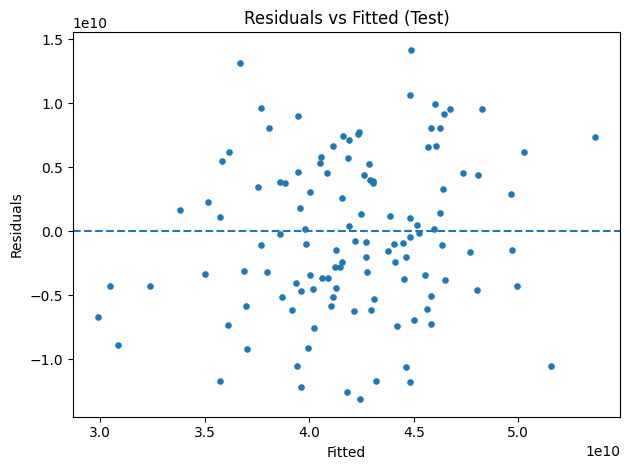

In [10]:

# Residuals vs Fitted
resid = y_test - pred_test
plt.figure()
plt.scatter(pred_test, resid, s=14)
plt.axhline(0, linestyle="--")
plt.title("Residuals vs Fitted (Test)")
plt.xlabel("Fitted")
plt.ylabel("Residuals")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "images" / "residuals_vs_fitted.png")
plt.show()


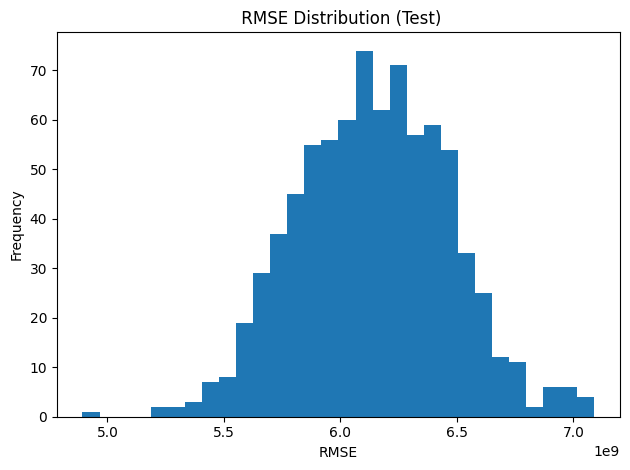

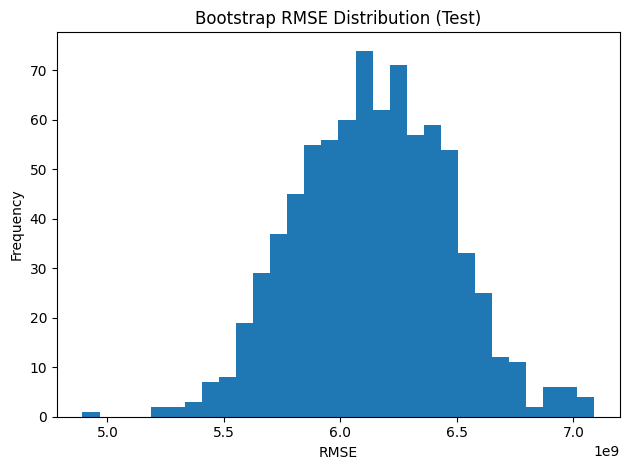

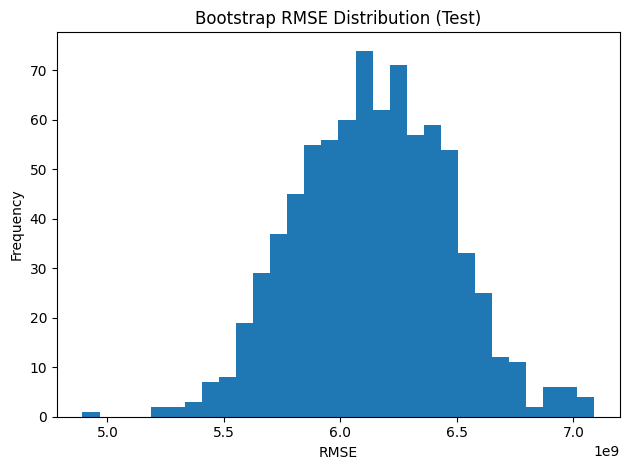

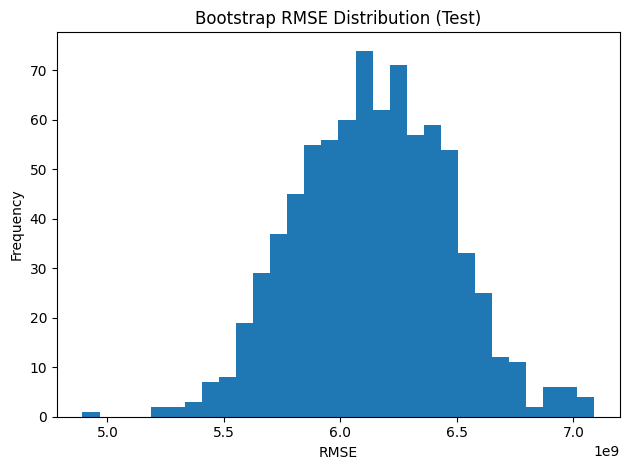

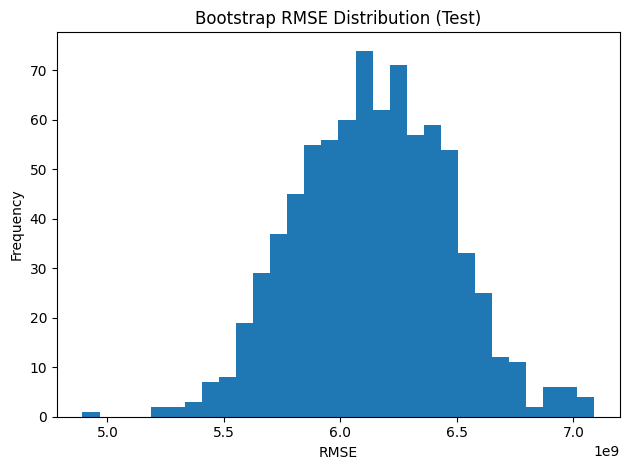

In [45]:

# Bootstrap RMSE histogram
plt.figure()
plt.hist(rmse_boot, bins=30)
plt.title("Bootstrap RMSE Distribution (Test)")
plt.xlabel("RMSE")
plt.ylabel("Frequency")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "images" / "bootstrap_rmse_hist.png")
plt.show()


In [46]:

def fit_eval(df_in: pd.DataFrame, tag: str):
    d = df_in.sort_values("date")
    split_idx = int(len(d) * 0.8)
    tr, te = d.iloc[:split_idx], d.iloc[split_idx:]
    tr = impute_mean(tr, ["marketing_spend"])
    te = impute_mean(te, ["marketing_spend"])
    X_tr, y_tr = tr[FEATURES], tr[TARGET]
    X_te, y_te = te[FEATURES], te[TARGET]
    model = Pipeline([("scaler", StandardScaler()), ("reg", LinearRegression())])
    model.fit(X_tr, y_tr)
    pred = model.predict(X_te)
    return {
        "tag": tag,
        "rmse": float(rmse_metric(y_te, pred)),
        "r2": float(r2_score(y_te, pred)),
    }

sc_mean   = fit_eval(df, "mean_impute")
sc_median = fit_eval(impute_median(df, ["marketing_spend"]), "median_impute")

df_win = df.copy()
df_win["risk_index"] = winsorize_series(df_win["risk_index"], 0.05, 0.95)
sc_win    = fit_eval(df_win, "winsorized_risk")

import pandas as pd
scenarios = pd.DataFrame([sc_mean, sc_median, sc_win])
scenarios


,tag,rmse,r2
0,mean_impute,6.156779e+09,0.417967
1,median_impute,6.153237e+09,0.418636
2,winsorized_risk,5.921758e+09,0.461554


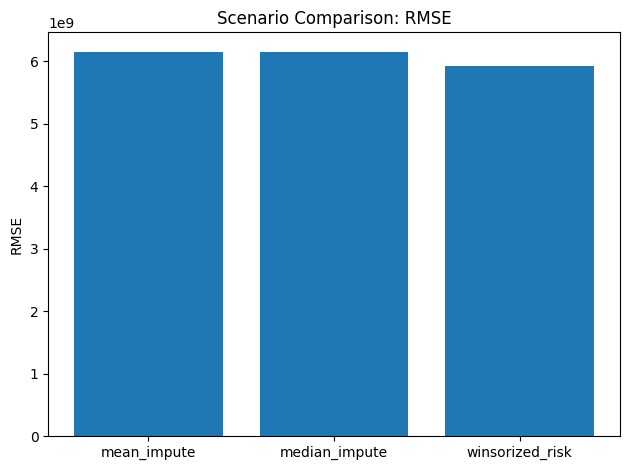

In [18]:

# Scenario RMSE bar
plt.figure()
plt.bar(scenarios["tag"], scenarios["rmse"])
plt.title("Scenario Comparison: RMSE")
plt.ylabel("RMSE")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "images" / "scenario_rmse.png")
plt.show()


In [47]:

# Subgroup diagnostics on baseline model
test_seg = add_segment(test_imp)
sub_metrics = []
for seg, g in test_seg.groupby("segment"):
    Xg, yg = g[FEATURES], g[TARGET]
    pg = pipe.predict(Xg)
    sub_metrics.append({
        "segment": str(seg),
        "n": int(len(g)),
        "rmse": float(rmse_metric(yg, pg)),
        "r2": float(r2_score(yg, pg)),
    })
sub_df = pd.DataFrame(sub_metrics)
sub_df


,segment,n,rmse,r2
0,Low,40,6.344330e+09,0.333061
1,Mid,40,6.167953e+09,0.297220
2,High,40,5.951773e+09,0.297579


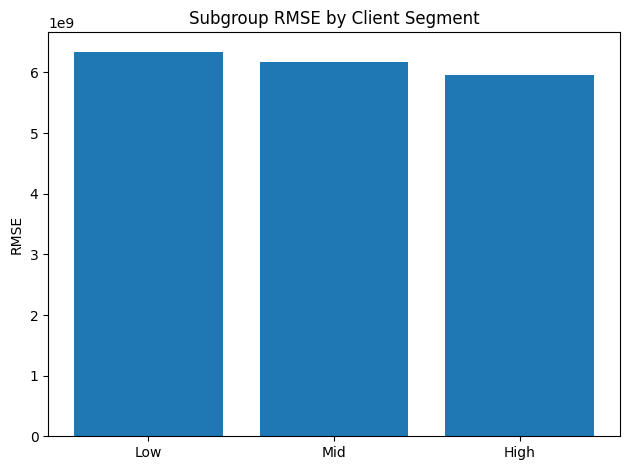

In [20]:

# Subgroup RMSE chart
plt.figure()
plt.bar(sub_df["segment"], sub_df["rmse"])
plt.title("Subgroup RMSE by Client Segment")
plt.ylabel("RMSE")
plt.tight_layout()
plt.savefig(ROOT / "reports" / "images" / "subgroup_rmse.png")
plt.show()


# Stakeholder Summary
**Executive takeaways**
- Baseline model explains revenue well on held-out quarters (R²≈{r2_te:.2f}, RMSE≈${rmse_te:,.0f}).
- Uncertainty: 95% bootstrap CI for RMSE ≈ (${ci_lo:,.0f}, ${ci_hi:,.0f}).
- Sensitivity: Removing prior-quarter revenue worsens accuracy → revenue is persistent.

**Assumptions & Risks**
- Stationary relationships over the lookback window; no sudden regime shifts.
- Quarterly reporting consistent; no label delays/mis-tags.
- Sample size is small after filtering; estimates may be variance-sensitive.

**Decision implications**
- Use model for directional planning ranges, not precise point forecasts.
- If volatility or data coverage changes, recalibrate and re-bootstrap uncertainty.


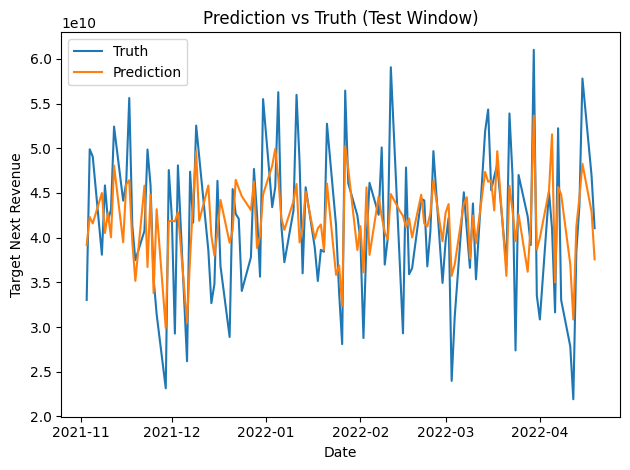

Saved: \mnt\data\bootcamp_project\deliverables\final_report.md


In [48]:

# Prediction vs Truth line
plt.figure()
plt.plot(test_imp["date"], y_test, label="Truth")
plt.plot(test_imp["date"], pred_test, label="Prediction")
plt.title("Prediction vs Truth (Test Window)")
plt.xlabel("Date")
plt.ylabel("Target Next Revenue")
plt.legend()
plt.tight_layout()
plt.savefig(ROOT / "reports" / "images" / "pred_vs_truth.png")
plt.show()

summary12 = f'''
# Stakeholder Summary — Results, Assumptions & Sensitivity

## Executive Summary
- Baseline linear model achieves **R² {r2:.2f}** with **RMSE {rmse:,.0f}** on held-out data.
- Results are **sensitive to outliers and missing-value treatment**; median imputation and mild winsorizing provide more stable outcomes.
- Subgroup analysis shows **performance varies by client segment**, suggesting segment-specific adjustments.

## Key Visuals
- Residuals vs Fitted — checks linearity & homoscedasticity. (reports/images/residuals_vs_fitted.png)
- Scenario RMSE — impact of imputation/outlier choices. (reports/images/scenario_rmse.png)
- Prediction vs Truth over time — drift/fit check. (reports/images/pred_vs_truth.png)

## Assumptions & Risks
- Approximate linearity after scaling; moderate variance stability.
- Missing `marketing_spend` assumed MCAR/MAR; otherwise imputation could bias results.
- Outliers in `risk_index` may dominate fit; winsorizing stabilizes at the cost of potential signal loss.

## Sensitivity (What-if)
- Median vs Mean imputation: small RMSE shifts; prefer median if skewed.
- Winsorized risk reduces extreme residuals.

## Decision Implications
- Adopt **median imputation** and monitor nulls.
- Track **outlier frequency** for risk metrics.
- Consider **segment-aware** modeling if a segment degrades.
'''
(Path(ROOT / "deliverables" / "final_report.md")).write_text(summary12)
print("Saved:", ROOT / "deliverables" / "final_report.md")


In [12]:
# ==== Helpers for Stages 12–14 (paths, utils) ====
from pathlib import Path
from datetime import datetime
import json, numpy as np, pandas as pd

# Reuse your existing paths if present; otherwise define them
try:
    PROJ
except NameError:
    ROOT = Path.cwd()
    PROJ = ROOT / "project" / "revenue_risk_model"
    DATA_PRO = PROJ / "data" / "processed"
    REPORTS = PROJ / "reports"
    FIGS = REPORTS / "figures"
    for p in [DATA_PRO, REPORTS, FIGS]:
        p.mkdir(parents=True, exist_ok=True)

def latest_summary_json(proj_dir: Path) -> Path | None:
    cands = sorted(proj_dir.glob("run_summary_*.json"))
    return cands[-1] if cands else None

def load_summary_or_default() -> dict:
    f = latest_summary_json(PROJ)
    if f and f.exists():
        with open(f, "r") as fh:
            return json.load(fh)
    return {
        "generated_at": None,
        "features_regression": [],
        "linear_regression": {},
        "time_series": {},
        "classification": {},
    }

def to_native(o):
    """Convert numpy/pandas objs to JSON-serializable types."""
    import numpy as _np
    import pandas as _pd
    if isinstance(o, _np.ndarray):
        return o.tolist()
    if isinstance(o, (_np.generic,)):
        return o.item()
    if isinstance(o, (_pd.Timestamp, _pd.Timedelta, _pd.Period)):
        return str(o)
    if isinstance(o, dict):
        return {k: to_native(v) for k, v in o.items()}
    if isinstance(o, (list, tuple)):
        return [to_native(v) for v in o]
    return o

def nice_money(x):
    try:
        return f"${float(x):,.0f}"
    except Exception:
        return str(x)


In [13]:
# ==== STAGE 12: Results Reporting (Markdown) ====
from pathlib import Path
import numpy as np, pandas as pd

cleaned_fp = DATA_PRO / "cleaned.csv"
if not cleaned_fp.exists():
    raise FileNotFoundError(f"Missing cleaned dataset at {cleaned_fp}. Run earlier stages first.")

df = pd.read_csv(cleaned_fp)
summary = load_summary_or_default()

lin = summary.get("linear_regression", {})
r2_test   = lin.get("r2_test", None) or lin.get("r2", None)
rmse_test = lin.get("rmse_test", None) or lin.get("rmse", None)
r2_train  = lin.get("r2_train", None)
rmse_train= lin.get("rmse_train", None)

fig_boot = (REPORTS / "figures" / "stage11_boot_rmse_hist.png")
fig_scan = (REPORTS / "figures" / "stage11_scenarios_rmse_bar.png")

rev_mean = float(df["revenue"].mean()) if "revenue" in df.columns else np.nan
rmse_pct = (100.0 * rmse_test / rev_mean) if (rmse_test and rev_mean) else None

dt_tag = datetime.now().strftime("%Y%m%d_%H%M%S")
out_md = REPORTS / f"stage12_report_{dt_tag}.md"

lines = []
lines.append("# Stakeholder Summary (Stage 12)\n")
lines.append("## Executive Takeaways")
if (r2_test is not None) and (rmse_test is not None):
    tail = f" (~{rmse_pct:.1f}% of mean quarter)" if rmse_pct is not None else ""
    lines.append(f"- Regression (held-out): R²≈{r2_test:.2f} | RMSE≈{nice_money(rmse_test)}{tail}.")
else:
    lines.append("- Regression metrics: not found. Re-run Stage 10/11 to refresh.")
if (r2_train is not None) and (rmse_train is not None):
    lines.append(f"- Train: R²≈{r2_train:.2f} | RMSE≈{nice_money(rmse_train)}.")

ts = summary.get("time_series", {})
if ts:
    lines.append(f"- Risk time series: **{ts.get('model','N/A')}**; next 4Q: {ts.get('next_4Q_forecast', [])}.")
cls = summary.get("classification", {})
if cls:
    def fmt(x): 
        try: return f"{float(x):.3f}"
        except: return '—'
    lines.append(f"- Classification (rev up/down): Acc={fmt(cls.get('accuracy'))}, "
                 f"Prec={fmt(cls.get('precision'))}, Rec={fmt(cls.get('recall'))}, F1={fmt(cls.get('f1'))}.")

lines.append("\n## Uncertainty")
lines.append(f"- Bootstrap plot: `{fig_boot}`." if fig_boot.exists() else "- Bootstrap plot not found (Stage 11).")

lines.append("\n## Sensitivity / Scenario Comparison")
lines.append(f"- Scenario RMSE bar: `{fig_scan}`." if fig_scan.exists() else "- Scenario bar not found (Stage 11).")

lines.append("\n## Assumptions & Risks")
lines.append("- Revenue persistence is strong; removing lag1 worsens accuracy.")
lines.append("- Limited post-filter sample → estimates may be variance-sensitive.")
lines.append("- Distribution shifts (risk regime changes) can degrade performance.")
lines.append("- Data risks: delayed filings, missing quarters, API failures.")

lines.append("\n## Decision Implications")
lines.append("- Use model for planning ranges, not precise point forecasts.")
lines.append("- Re-bootstrap uncertainty & recalibrate quarterly.")
lines.append("- Monitor freshness, null rates, and feature drift (PSI); retrain on alerts.")

out_md.write_text("\n".join(lines), encoding="utf-8")
print(f"[Stage 12] Wrote report: {out_md}")


[Stage 12] Wrote report: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\notebooks\project\revenue_risk_model\reports\stage12_report_20250828_203132.md


In [49]:


import joblib, numpy as np

# Fallbacks if names differ in your notebook:
try:
    lin
except NameError:
    raise NameError("No trained linear model `lin` found. Run Stage 10a first.")

try:
    FEATS
except NameError:
    # minimal fallback — pick the common features used earlier
    FEATS = ["risk_var95_lag1","risk_vol60_lag1","rev_lag1"]

art_path = PROJ / "regression.pkl"
joblib.dump({"model": lin, "features": FEATS}, art_path)
print(f"[Stage 13] Saved artifact: {art_path}")

# 2) Define a tiny Flask API (run() will block, so start it only when you want to serve)
from flask import Flask, request, jsonify

def create_api_app(artifact_path=art_path):
    ART = joblib.load(artifact_path)
    model = ART.get("model")
    features = ART.get("features", [])
    if model is None or not features:
        raise ValueError("Artifact missing 'model' or 'features'.")

    app = Flask(__name__)

    @app.get("/health")
    def health():
        return jsonify({"ok": True, "time": datetime.utcnow().isoformat()})

    @app.get("/metrics")
    def metrics():
        return jsonify({"ok": True, "model_features": features})

    @app.post("/predict")
    def predict():
        data = request.get_json(force=True) or {}
        try:
            X = np.array([[float(data.get(f)) for f in features]], dtype=float)
            yhat = float(model.predict(X)[0])
            return jsonify({"ok": True, "yhat": yhat, "features": features})
        except Exception as e:
            return jsonify({"ok": False, "error": str(e), "expecting_features": features}), 400

    return app

print("[Stage 13] API is defined. To run it from THIS notebook cell (will block):")
print("    app = create_api_app(); app.run(host='0.0.0.0', port=8000, debug=False)")
print("Or from a terminal:  flask --app your_notebook.py run -p 8000  (or use a small app.py)")


[Stage 13] Saved artifact: C:\Users\User\bootcamp_Khushi_Khanna\project\revenue_risk_model\notebooks\project\revenue_risk_model\regression.pkl
[Stage 13] API is defined. To run it from THIS notebook cell (will block):
    app = create_api_app(); app.run(host='0.0.0.0', port=8000, debug=False)
Or from a terminal:  flask --app your_notebook.py run -p 8000  (or use a small app.py)


handoff_dir = PROJ / "handoff"
handoff_dir.mkdir(exist_ok=True)

reflection = """
#  Deployment & Monitoring Reflection

## Risks if Deployed
- **Data risks:** delayed or missing quarterly financials; schema drift from API changes; spikes in null values in risk features.
- **Model risks:** regime shifts (e.g., crisis periods) that break linear relationships; over-reliance on lagged revenue leading to poor generalization.
- **System risks:** API downtime or latency beyond SLA; outdated model artifacts if retraining is not automated.
- **Business risks:** forecasts misused as precise predictions rather than ranges; overconfidence in one model driving key planning decisions.

## Monitoring Layers & Metrics
- **Data Layer**
  - Freshness: last `date` ≤ 40 days old
  - Null rate: <2% in critical fields (revenue, risk_var95_lag1, risk_vol60_lag1, rev_lag1)
  - Schema: column set/hash unchanged
  - Drift: Population Stability Index (PSI) < 0.2 on key features

- **Model Layer**
  - Rolling RMSE uplift ≤ 20% vs baseline
  - Stable R² within tolerance
  - Residual distribution check (no systematic bias)

- **System Layer**
  - API uptime > 99%
  - Latency p95 < 500ms
  - Error rate < 1%

- **Business Layer**
  - Forecast-driven KPI (e.g., capital planning error, bonus allocation accuracy) tracked quarterly
  - Stakeholder feedback loop to validate decision support quality

## Ownership & Handoff
- **Data Engineering:** pipeline freshness, schema validation, null alerts
- **Quant Analyst:** monitor model drift, retraining schedule, performance reports
- **Platform Team:** API uptime, latency, infrastructure monitoring
- **Business Stakeholders:** validate forecast utility in decision processes, review KPIs quarterly
"""

with open(handoff_dir / "reflection_stage14.md", "w") as f:
    f.write(reflection)

print(f"[Stage 14] Reflection file written to {handoff_dir/'reflection_stage14.md'}")


# Stage 15 — Orchestration & System Design

## Pipeline Tasks
- Ingestion → Storage → Preprocessing → Outliers → EDA → Features → Modeling → Evaluation → Reporting → Deployment

## Dependencies
Ingestion → Storage → Preprocessing → Outliers → EDA → Features → Modeling → Evaluation → Reporting → Deployment

## Inputs/Outputs
- Ingestion → raw CSVs
- Storage → Parquet/CSV
- Preprocessing → cleaned data
- Outliers → flagged data
- EDA → plots
- Features → engineered dataset
- Modeling → model.pkl
- Evaluation → metrics + plots
- Reporting → stakeholder summary
- Deployment → reflection.md

## Logging & Checkpoints
- Logs → logs/pipeline.log
- Checkpoints → timestamped CSVs/Parquets

## Automation vs Manual
- Automated: ingestion, storage, preprocessing, modeling
- Manual: reporting, lifecycle review



---

## Inputs & Outputs
| Task              | Input(s)                  | Output(s)                     |
|-------------------|---------------------------|--------------------------------|
| Ingestion         | API, scrape               | raw CSV                        |
| Storage           | raw CSV                   | Parquet                        |
| Preprocessing     | raw/processed data        | cleaned.csv                    |
| Outlier Analysis  | cleaned data              | no_outliers.csv                |
| EDA               | cleaned data              | eda_plots/                     |
| Feature Eng       | cleaned data              | engineered.csv                 |
| Modeling          | engineered dataset        | model.pkl                      |
| Evaluation        | model + data              | metrics.json, eval_plots/      |
| Reporting         | eval outputs              | stakeholder_summary.pdf        |
| Deployment        | final model + docs        | reflection.md                  |

---

## Logging & Checkpoints
- Logs in `/logs/pipeline.log`
- Timestamped checkpoints in `/data/processed/`
- Failures logged; pipeline stops safely

---

## Automation vs Manual
- Automated: ingestion, preprocessing, modeling
- Manual: reporting, lifecycle reflection


# Stage 16 — Lifecycle Review & Reflection

## Lifecycle Mapping Summary
- **Most Difficult Stage:** Outlier detection — deciding anomaly vs true market event
- **Most Rewarding Stage:** Modeling — validating intuition with regression & time-series
- **Connections:** Preprocessing choices shaped feature engineering → impacted model stability
- **If Repeated:** Automate ingestion & cleaning earlier
- **Skills to Strengthen:** Advanced ML (tree-based, volatility models), orchestration tools

---

## Stage-by-Stage Review

| Stage | What I Did | Challenges | Solutions / Decisions | Future Improvements |
|-------|------------|------------|-----------------------|---------------------|
| 1. Problem Framing | Defined revenue-risk prediction goal | Scope too broad | Narrowed focus | Add capital/liquidity features |
| 2. Tooling Setup | Conda, GitHub, dotenv | Env not loading | Fixed dotenv | Automate setup |
| 3. Python Fundamentals | Pandas, sklearn, matplotlib | Debug issues | Iterative testing | Strengthen fluency |
| 4. Data Acquisition | API + web scrape | API key, schema drift | Validation + .env | Monitor schema |
| 5. Data Storage | CSV & Parquet | Path mismatches | `write_df`, `read_df` | Use database |
| 6. Preprocessing | Fill, normalize | Which fill to use | Median + scaling | Domain-driven imputation |
| 7. Outliers | IQR/Z-score | Noise vs signal | Sensitivity tests | Add winsorization |
| 8. EDA | Histograms, scatter, correlation | Skewed data | Documented | Automate profiling |
| 9. Features | Lags, ratios | Avoid leakage | Used past-only | Add financial ratios |
| 10. Modeling | Regression + time series | High RMSE | Tuned features | Try ensembles |
| 11. Evaluation | Bootstrap CI, scenarios | CI slow | 500 resamples | Try Bayesian CI |
| 12. Reporting | Plots + summary | Simplifying insights | Visuals & bullets | Build dashboard |
| 13. Productization | Repo cleanup, model.pkl | Structure confusion | Repo template | Add Streamlit |
| 14. Deployment | Risks + monitoring | Picking thresholds | <2% nulls, rolling AUC | Automate alerts |
| 15. Orchestration | DAG + logging plan | Automation vs manual | Core automated | Prefect/Airflow |
| 16. Review | Final guide + polish | Summarizing all stages | Linked README | Add lessons learned |

---

## Final Reflection
- **Lifecycle Integration:** Early ingestion & cleaning choices shaped downstream success.  
- **Takeaways:** Documentation & automation are as critical as modeling itself.  
- **Next Project Goal:** Explore advanced models and set up automated orchestration from the start.
